# Notebook 2: Professional Data Cleaning
**Project**: Loan Approval Prediction & Banking Analytics

---
## 1. Introduction
In this notebook, we perform data cleaning and auditing. Handling missing data and outliers is critical for banking applications to ensure compliance and model reliability.

### Cleaning Workflow:
1. Identify missing values.
2. Impute categorical variables with the **Mode**.
3. Impute continuous variables with the **Median** (to handle skewed distributions).
4. Identify and handle duplicate records.
5. Standardize categories and fix column data types.
6. Audit outliers.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw data
raw_path = os.path.join("..", "Dataset", "raw", "loan_prediction.csv")
df = pd.read_csv(raw_path)
print(f"Loaded raw data of shape: {df.shape}")

Loaded raw data of shape: (614, 13)


## 2. Auditing Missing Values

In [2]:
# Sum of missing values per column
missing_val = df.isnull().sum()
missing_pct = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing_val, missing_pct], axis=1, keys=['Missing Count', 'Percentage %'])
missing_table[missing_table['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Percentage %
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599


## 3. Data Imputation Strategy

### Categorical Columns:
We will impute missing values with the **Mode** (most frequent value) of each column:
- `Gender`
- `Married`
- `Dependents`
- `Self_Employed`
- `Credit_History`


In [3]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    print(f"Imputing missing values in '{col}' with Mode: {mode_val}")
    df[col] = df[col].fillna(mode_val)

Imputing missing values in 'Gender' with Mode: Male
Imputing missing values in 'Married' with Mode: Yes
Imputing missing values in 'Dependents' with Mode: 0
Imputing missing values in 'Self_Employed' with Mode: No
Imputing missing values in 'Credit_History' with Mode: 1.0


### Numerical Columns:
For continuous financial features (`LoanAmount`, `Loan_Amount_Term`), we will impute missing values with the **Median** because continuous distributions in income/loan amounts are typically skewed.


In [4]:
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in numerical_cols:
    median_val = df[col].median()
    print(f"Imputing missing values in '{col}' with Median: {median_val}")
    df[col] = df[col].fillna(median_val)

Imputing missing values in 'LoanAmount' with Median: 128.0
Imputing missing values in 'Loan_Amount_Term' with Median: 360.0


In [5]:
# Verify that no missing values remain
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 4. Duplicate Records Check

In [6]:
# Check for duplicates on Loan_ID
duplicates = df.duplicated(subset=['Loan_ID']).sum()
print(f"Number of duplicate Loan_IDs found: {duplicates}")

Number of duplicate Loan_IDs found: 0


## 5. Type Conversions & Clean-Up

In [7]:
# Convert Credit_History to integer
df['Credit_History'] = df['Credit_History'].astype(int)
# Convert Loan_Amount_Term to integer
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    int64  
 10  Credit_History     614 non-null    int64  
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(2), int64(3), object(8)
memory usage: 62.5+ KB


## 6. Outlier Assessment

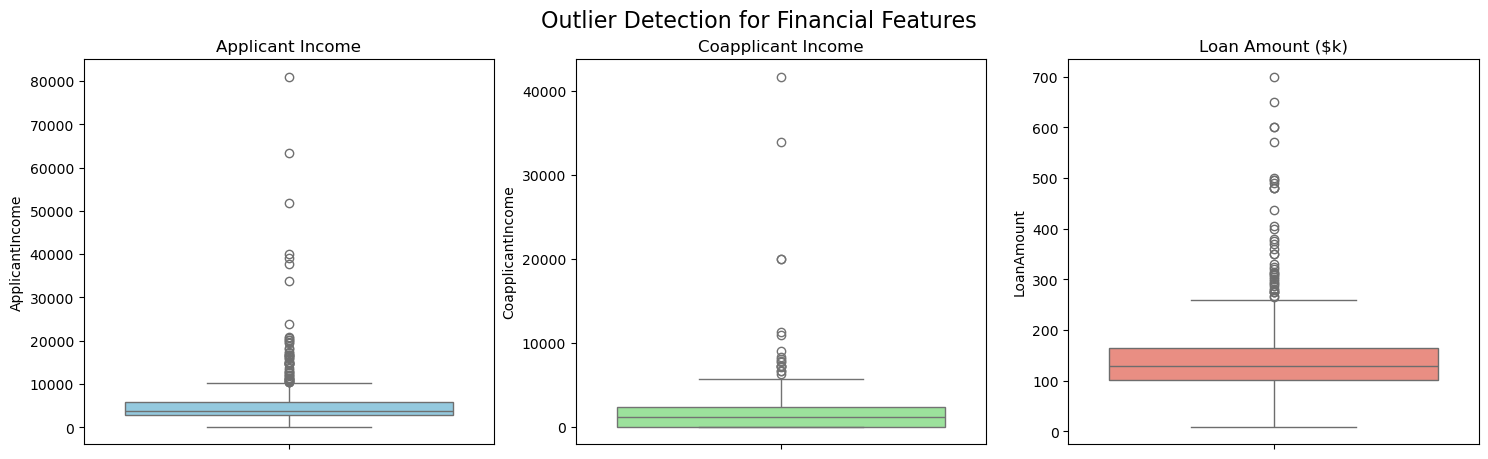

In [8]:
# Plot Boxplots for financial fields to visually check for extreme outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=df['ApplicantIncome'], ax=axes[0], color='skyblue')
axes[0].set_title('Applicant Income')

sns.boxplot(y=df['CoapplicantIncome'], ax=axes[1], color='lightgreen')
axes[1].set_title('Coapplicant Income')

sns.boxplot(y=df['LoanAmount'], ax=axes[2], color='salmon')
axes[2].set_title('Loan Amount ($k)')

plt.suptitle('Outlier Detection for Financial Features', fontsize=16)
os.makedirs("../Images", exist_ok=True)
plt.savefig("../Images/outlier_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

### Note on Outlier Policy:
While there are outliers in `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount`, these represent real high-net-worth loan applications rather than data entry errors. Therefore, we do not truncate or remove them. Instead, we will handle them in the feature engineering and modeling stages (e.g. using robust estimators, tree-based algorithms like XGBoost/CatBoost, or scaling).


## 7. Export Cleaned Dataset

In [9]:
# Export clean data
cleaned_data_path = os.path.join("..", "Dataset", "cleaned", "loan_cleaned.csv")
df.to_csv(cleaned_data_path, index=False)
print(f"Cleaned dataset saved successfully to: {cleaned_data_path}")

Cleaned dataset saved successfully to: ..\Dataset\cleaned\loan_cleaned.csv
